# Titanic Survival Prediction Advanced Exploratory Data Analysis

This notebook presents a comprehensive exploratory data analysis (EDA) of the Titanic dataset. The objective is to identify demographic, socioeconomic, and behavioral patterns associated with passenger survival.

The analysis focuses on:
- survival trends across different passenger groups
- missing data structure
- numerical feature distributions
- feature interactions
- socioeconomic effects
- potential predictive signals for machine learning models

The insights extracted from this EDA phase will guide subsequent feature engineering, preprocessing, and modeling decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn 

# Data reading

In [2]:
df=pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df_test=pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [8]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

The dataset contains demographic and travel-related information for passengers aboard the RMS Titanic.

Key variables include:
- Passenger Class (`Pclass`)
- Sex
- Age
- Fare
- Family Relationships (`SibSp`, `Parch`)
- Embarkation Port (`Embarked`)

The target variable is:
- `Survived`
    - 1 → survived
    - 0 → did not survive

The dataset contains both numerical and categorical variables.

# -------------------------------------

# EDA

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 891 records in the dataset
## Age column has 177 missing values 
## Embarked has 2 missing values
## cabin has 687 missing values

# -------------------------------------

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Key Insights from Numerical Features

- The survival rate = 38.4% (Class imbalance)
- Age contains nearly 20% missing values, requiring careful imputation.
- Fare distribution is highly skewed with significant outliers.
- Most passengers belonged to lower passenger classes.
- The majority of passengers traveled alone.
- Large family groups exist and may influence survival behavior.
- Socioeconomic status(Fare, Pclass) appears likely to play an important role in survival prediction.

# -------------------------------------

## EDA Plots 

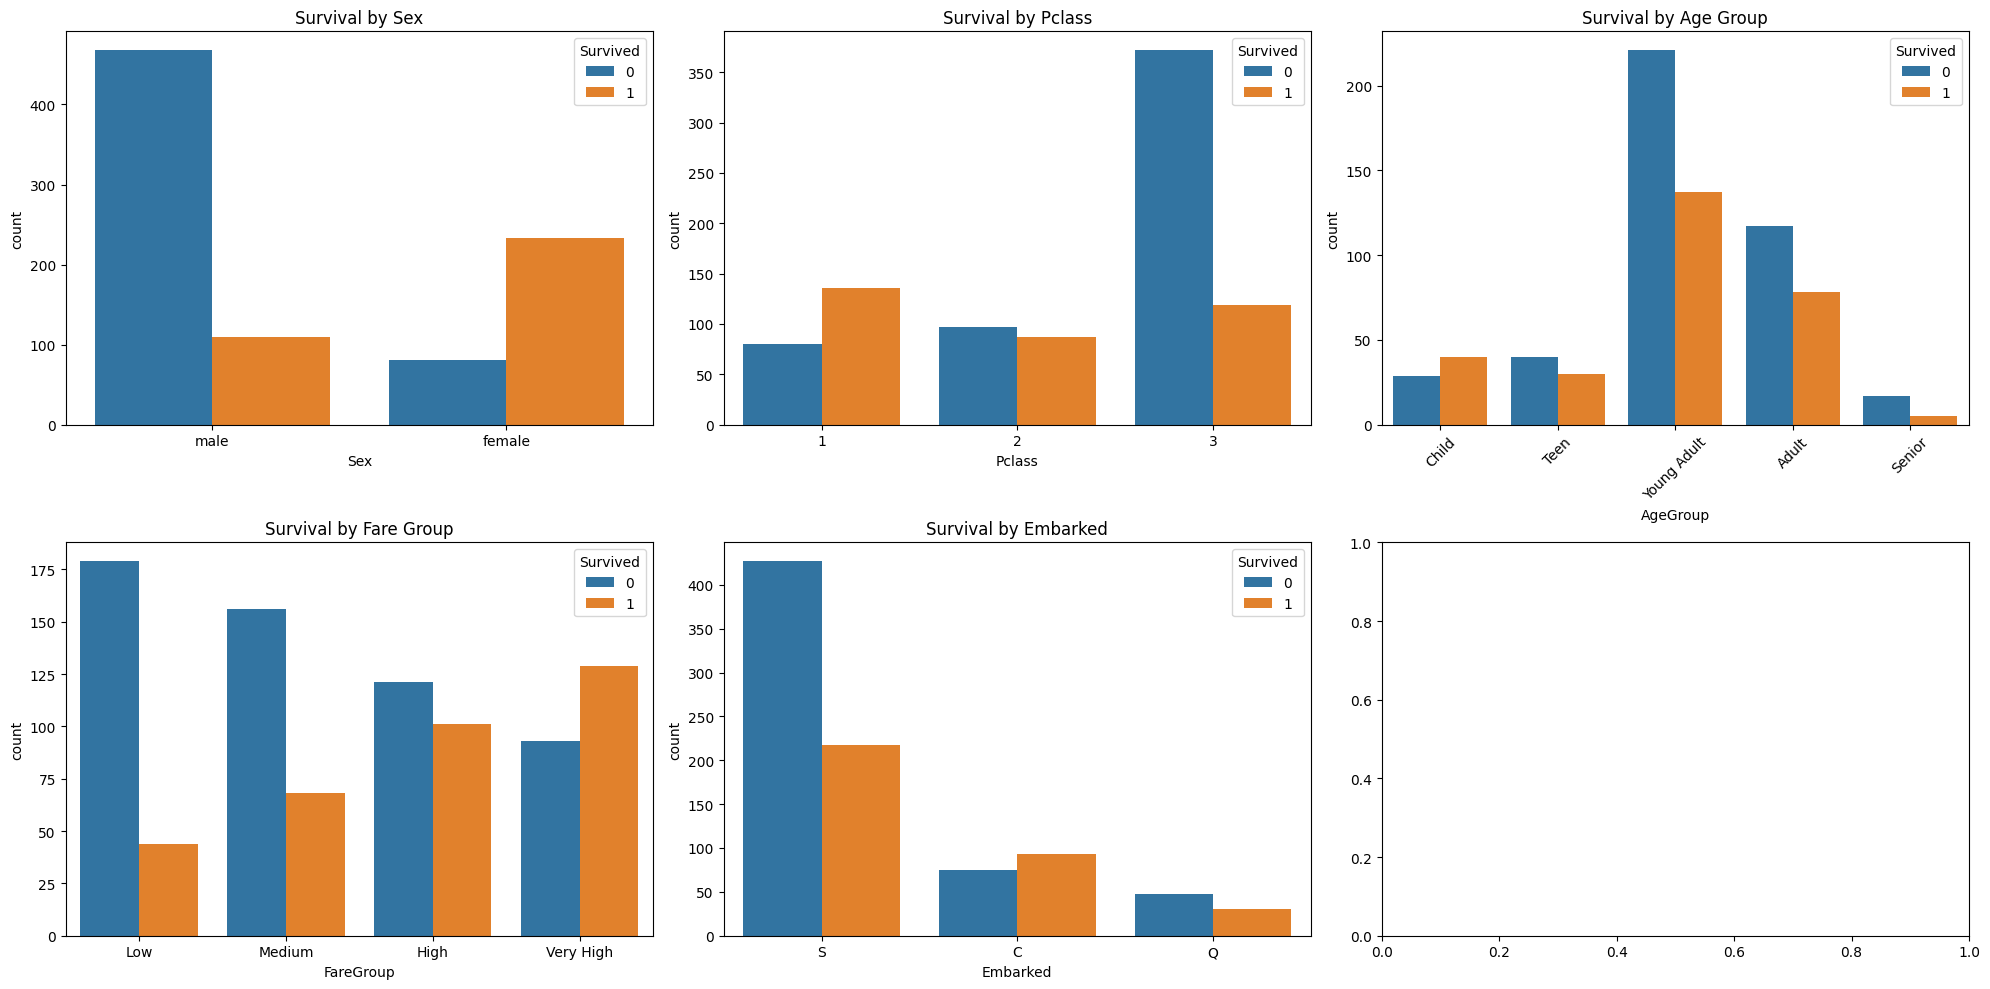

In [12]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

df['FareGroup'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=['Low','Medium','High','Very High']
)


#  Layout


fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Survival by Sex
sns.countplot(
    data=df,
    x='Sex',
    hue='Survived',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Survival by Sex')

# Survival by Pclass
sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Survival by Pclass')

# Survival by Age Group
sns.countplot(
    data=df,
    x='AgeGroup',
    hue='Survived',
    ax=axes[0, 2]
)
axes[0, 2].set_title('Survival by Age Group')
axes[0, 2].tick_params(axis='x', rotation=45)

# Survival by Fare Group
sns.countplot(
    data=df,
    x='FareGroup',
    hue='Survived',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Survival by Fare Group')

# Survival by Embarked
sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Survival by Embarked')


plt.tight_layout()
plt.show()

## The strongest predictors of survival were sex > class > fare > age
### Summary
| Feature | Impact on Survival |
|---|---|
| Sex | Strongest predictor — females survived far more |
| Pclass | Higher class = higher survival |
| Fare | Higher fare = higher survival |
| Age Group | Children had better odds; Seniors worst |
| Embarked | Cherbourg passengers fared best |

# -------------------------------------

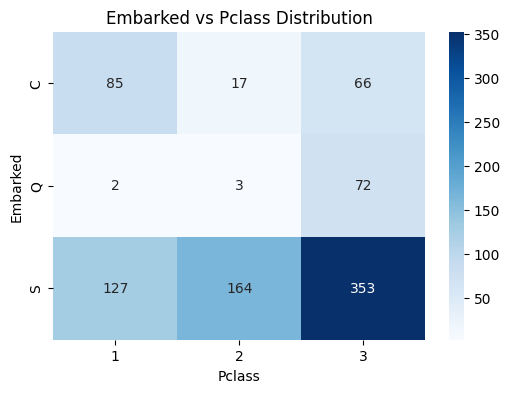

In [3]:
ct = pd.crosstab(
    df['Embarked'],
    df['Pclass']
)

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Embarked vs Pclass Distribution')

plt.show()

## Insights
| Port | 1st | 2nd | 3rd | Total | % 1st Class |
|------|-----|-----|-----|-------|-------------|
| **C** | 85 | 17 | 66 | 168 | **51%** |
| **Q** | 2 | 3 | 72 | 77 | 3% |
| **S** | 127 | 164 | 353 | 644 | 20% |

# -------------------------------------

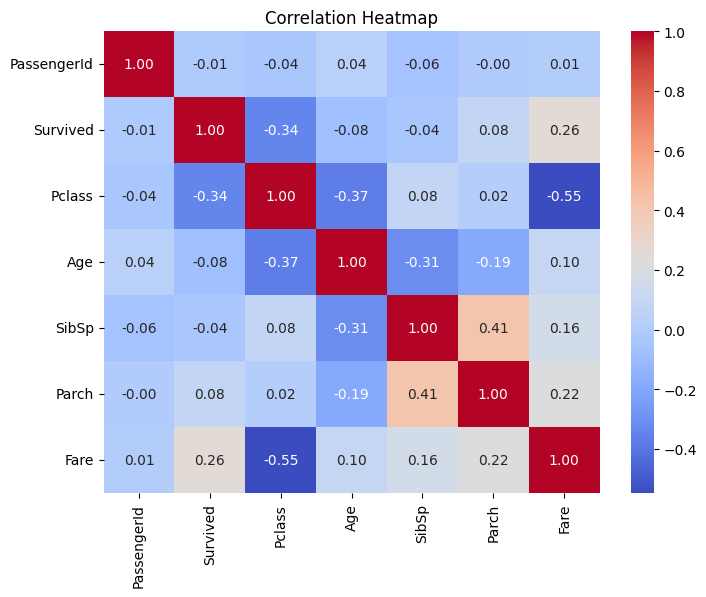

In [5]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

# Pclass negatively correlated with survival
# Fare positively correlated with survival

# -------------------------------------

# Feature Engineered (FamilySize)

In [8]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Distribution Plots

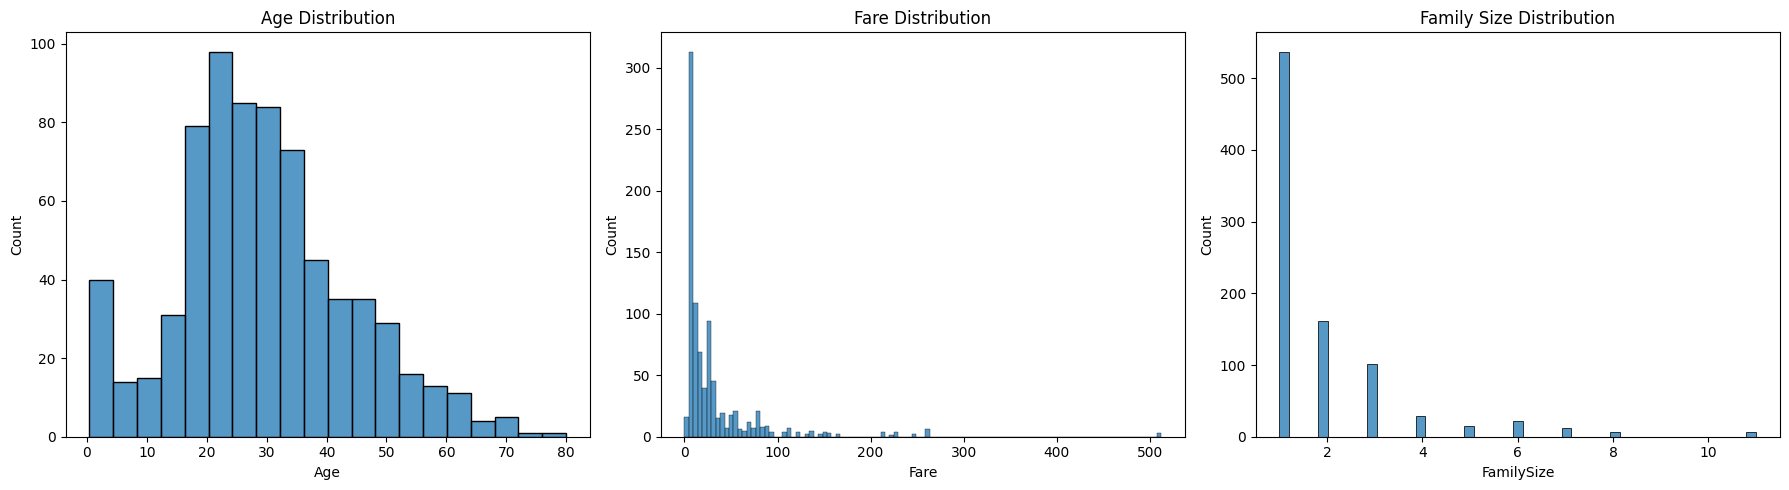

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['Age'], kde=False, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['Fare'], kde=False, ax=axes[1])
axes[1].set_title('Fare Distribution')

sns.histplot(df['FamilySize'], kde=False, ax=axes[2])
axes[2].set_title('Family Size Distribution')

plt.tight_layout()
plt.show()

# Age --> normal distribution
# Fare is heavily skewed 

# -------------------------------------

# Log transformation to (Fare) 

In [3]:
df['LogFare'] = np.log1p(df['Fare'])

# KDE Survival Distributions

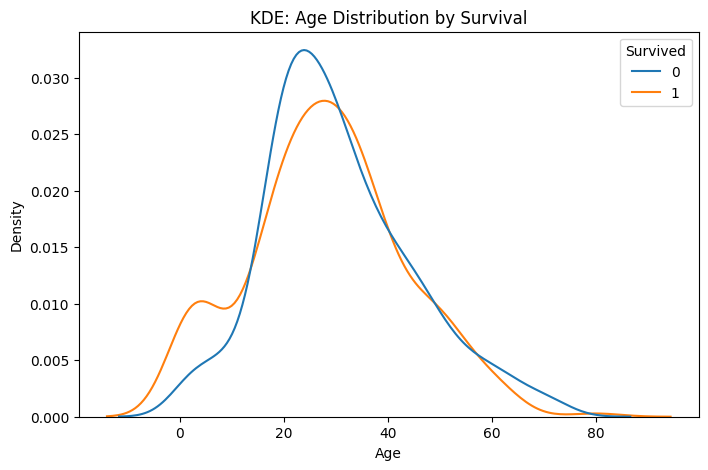

In [11]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='Age',
    hue='Survived',
    common_norm=False
)

plt.title('KDE: Age Distribution by Survival')

plt.show()

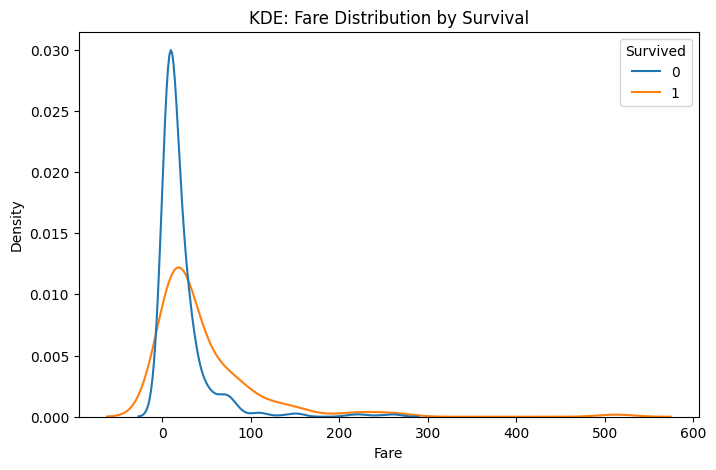

In [15]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='Fare',
    hue='Survived',
    common_norm=False
)

plt.title('KDE: Fare Distribution by Survival')

plt.show()

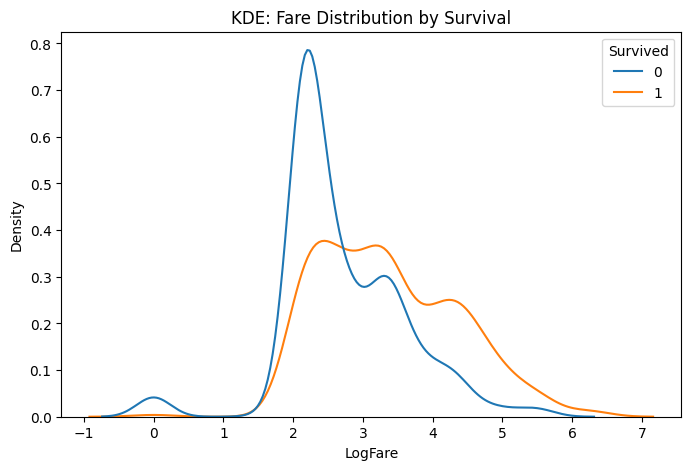

In [4]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='LogFare',
    hue='Survived',
    common_norm=False
)

plt.title('KDE: Fare Distribution by Survival')

plt.show()

# KDE plots show that Age and Fare are the most discriminative features for survival prediction.